# Halo Core Response by Mass Bin

This notebook generates a single figure showing how halo cores (r < 0.5 R₂₀₀) at different masses contribute to the weak lensing peak count response as a function of S/N threshold.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import h5py
import os
import scienceplots
plt.style.use(['science', 'notebook'])

# Plot settings
# plt.rcParams.update({'font.size': 12, 'figure.dpi': 150})

In [2]:
# Configuration
STATS_BASE = '/mnt/home/mlee1/ceph/hydro_replace_stats'
z_idx = 20  # z_s ~ 1.0

# Mass and radius bin definitions
mass_bins = ['1.00e12', '3.16e12', '1.00e13', '3.16e13']
mass_bin_upper = ['3.16e12', '1.00e13', '3.16e13', '1.00e15']
radius_bins = [('0.0', '0.5'), ('0.5', '1.0'), ('1.0', '3.0'), ('3.0', '5.0')]

# Build list of discrete models
DISC_MODELS = []
for ml, mu in zip(mass_bins, mass_bin_upper):
    for ri, ro in radius_bins:
        DISC_MODELS.append(f'hydro_replace_Ml_{ml}_Mu_{mu}_Ri_{ri}_Ro_{ro}')

In [3]:
def load_stats(model, keys=['peaks', 'sn_bin_edges']):
    """Load statistics for a model."""
    path = os.path.join(STATS_BASE, model, 'stats.h5')
    if not os.path.exists(path):
        return None
    data = {}
    with h5py.File(path, 'r') as f:
        for key in keys:
            if key in f:
                data[key] = f[key][:]
    return data if data else None

# Load base models (DMO and Hydro)
print("Loading DMO and Hydro statistics...")
base_stats = {
    'dmo': load_stats('dmo'),
    'hydro': load_stats('hydro')
}

# Load discrete tile models
print("Loading discrete tile models...")
disc_stats = {}
for model in DISC_MODELS:
    stats = load_stats(model)
    if stats is not None:
        disc_stats[model] = stats
print(f"Loaded {len(disc_stats)} discrete models")

# Load cumulative model for peaks: M > 10^12.5, r < 0.5 R₂₀₀
cumulative_core_model_peaks = 'hydro_replace_Ml_3.16e12_Mu_1.00e15_Ri_0.0_Ro_0.5'
cumulative_core_stats_peaks = load_stats(cumulative_core_model_peaks, keys=['peaks', 'sn_bin_edges'])
if cumulative_core_stats_peaks is not None:
    print(f"Loaded cumulative core model for peaks: {cumulative_core_model_peaks}")
else:
    print(f"WARNING: Could not load cumulative core model: {cumulative_core_model_peaks}")

Loading DMO and Hydro statistics...


Loading discrete tile models...
Loaded 16 discrete models
Loaded cumulative core model for peaks: hydro_replace_Ml_3.16e12_Mu_1.00e15_Ri_0.0_Ro_0.5


In [4]:
def compute_deltaF_vs_nu(model_stats, base_stats, z_idx):
    """Compute ΔF for each S/N bin."""
    sn_edges = base_stats['hydro']['sn_bin_edges']
    sn_centers = 0.5 * (sn_edges[:-1] + sn_edges[1:])
    
    # Sum over realizations for each S/N bin
    dmo = base_stats['dmo']['peaks'][:, z_idx, :].sum(axis=0)
    hydro = base_stats['hydro']['peaks'][:, z_idx, :].sum(axis=0)
    replace = model_stats['peaks'][:, z_idx, :].sum(axis=0)
    
    # Cumulative counts from high S/N to low
    N_dmo = np.cumsum(dmo[::-1])[::-1]
    N_hydro = np.cumsum(hydro[::-1])[::-1]
    N_replace = np.cumsum(replace[::-1])[::-1]
    
    # Response fraction
    delta = N_hydro - N_dmo
    F = np.where(np.abs(delta) > 50, (N_replace - N_dmo) / delta, np.nan)
    
    return sn_centers, F

# Compute ΔF vs ν for all discrete tiles
print("Computing response fractions...")
tile_data = {}  # (mass_idx, radius_idx) -> (nu_values, F_values)

for i, (ml, mu) in enumerate(zip(mass_bins, mass_bin_upper)):
    for j, (ri, ro) in enumerate(radius_bins):
        model = f'hydro_replace_Ml_{ml}_Mu_{mu}_Ri_{ri}_Ro_{ro}'
        if model in disc_stats:
            nu, F = compute_deltaF_vs_nu(disc_stats[model], base_stats, z_idx)
            tile_data[(i, j)] = (nu, F)

print(f"Computed response for {len(tile_data)} tiles")

Computing response fractions...
Computed response for 16 tiles


/tmp/ipykernel_1599462/2851410092.py:88: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


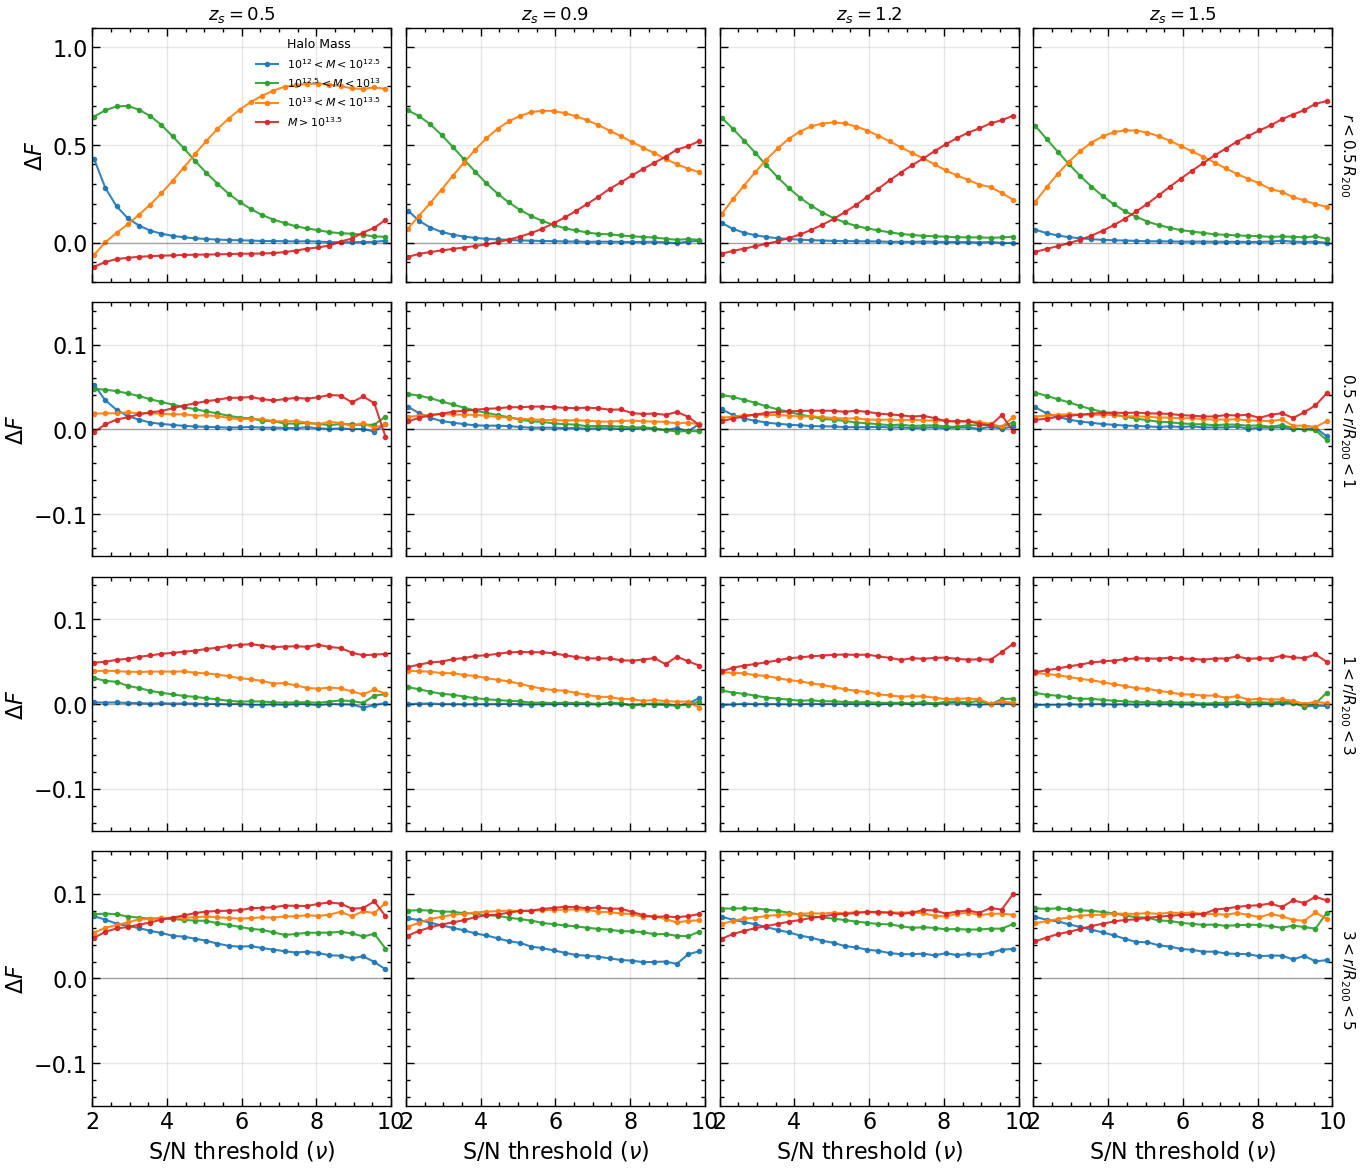


Saved to figures/radial_response_all_shells_multiZ.png and .pdf


In [5]:
# ============================================================================
# PLOT: Full Response by Radial Shell - Peaks AND Minima - Multi-redshift
# ============================================================================

# Redshift indices and labels
z_indices = [13, 20, 25, 30]
z_labels = ['$z_s = 0.5$', '$z_s = 0.9$', '$z_s = 1.2$', '$z_s = 1.5$']

# Get S/N bin centers
sn_edges = base_stats['hydro']['sn_bin_edges']
sn_centers = 0.5 * (sn_edges[:-1] + sn_edges[1:])

# Radial shell definitions
radial_shells = [
    ('0.0', '0.5', '$r < 0.5\\,R_{200}$'),
    ('0.5', '1.0', '$0.5 < r/R_{200} < 1$'),
    ('1.0', '3.0', '$1 < r/R_{200} < 3$'),
    ('3.0', '5.0', '$3 < r/R_{200} < 5$'),
]

# Colors and labels for mass bins
colors = ['#1f77b4', '#2ca02c', '#ff7f0e', '#d62728']
mass_labels = [
    '$10^{12} < M < 10^{12.5}$',
    '$10^{12.5} < M < 10^{13}$', 
    '$10^{13} < M < 10^{13.5}$',
    '$M > 10^{13.5}$'
]

# Create 16-panel figure (4 rows for radial shells × 4 columns for redshifts)
fig, axes = plt.subplots(4, 4, figsize=(16, 14), sharex=True, sharey='row',
                         gridspec_kw={'hspace': 0.08, 'wspace': 0.05})

for row, (ri, ro, r_label) in enumerate(radial_shells):
    for col, (z_idx_plot, z_label) in enumerate(zip(z_indices, z_labels)):
        ax = axes[row, col]
        
        # Compute response for each mass bin
        for i in range(4):
            model = f'hydro_replace_Ml_{mass_bins[i]}_Mu_{mass_bin_upper[i]}_Ri_{ri}_Ro_{ro}'
            if model in disc_stats:
                # --- PEAKS (positive ν) ---
                dmo_p = base_stats['dmo']['peaks'][:, z_idx_plot, :].sum(axis=0)
                hydro_p = base_stats['hydro']['peaks'][:, z_idx_plot, :].sum(axis=0)
                replace_p = disc_stats[model]['peaks'][:, z_idx_plot, :].sum(axis=0)
                
                N_dmo_p = np.cumsum(dmo_p[::-1])[::-1]
                N_hydro_p = np.cumsum(hydro_p[::-1])[::-1]
                N_replace_p = np.cumsum(replace_p[::-1])[::-1]
                
                delta_p = N_hydro_p - N_dmo_p
                F_p = np.where(np.abs(delta_p) > 50, (N_replace_p - N_dmo_p) / delta_p, np.nan)
                F_p_plot = np.clip(F_p, -1.5, 1.5)
                F_p_plot = np.where(sn_centers >= 2, F_p_plot, np.nan)
                
                ax.plot(sn_centers, F_p_plot, 'o-', lw=1.5, markersize=3, 
                       color=colors[i], alpha=0.9, label=mass_labels[i] if (row==0 and col==0) else None)
        
        ax.axhline(0, color='k', ls='-', lw=1, alpha=0.3)
        ax.axvline(0, color='gray', ls='--', lw=1, alpha=0.3)
        ax.grid(True, alpha=0.3)
        ax.set_xlim(2, 10)
        
        # Add titles
        if row == 0:
            ax.set_title(z_label, fontsize=13)
        
        # Add radial shell label on right side
        if col == 3:
            ax.annotate(r_label, xy=(1.02, 0.5), xycoords='axes fraction',
                       fontsize=11, ha='left', va='center', rotation=-90)

# Set axis labels
for row in range(4):
    axes[row, 0].set_ylabel('$\\Delta F$')
for col in range(4):
    axes[3, col].set_xlabel('S/N threshold ($\\nu$)')

# Set y-limits for each row
axes[0, 0].set_ylim(-0.2, 1.1)  # Core: large response
axes[1, 0].set_ylim(-0.15, 0.15)  # 0.5-1.0 R200: small response
axes[2, 0].set_ylim(-0.15, 0.15)  # 1-3 R200: small response
axes[3, 0].set_ylim(-0.15, 0.15)  # 3-5 R200: minimal response

# Add legend
axes[0, 0].legend(loc='upper right', fontsize=8, title='Halo Mass', title_fontsize=9)

plt.tight_layout()
plt.savefig('figures/radial_response_all_shells_multiZ.png', dpi=150, bbox_inches='tight')
plt.savefig('figures/radial_response_all_shells_multiZ.pdf', format='pdf', bbox_inches='tight')
plt.show()

print("\nSaved to figures/radial_response_all_shells_multiZ.png and .pdf")

/tmp/ipykernel_1599462/3295273063.py:103: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


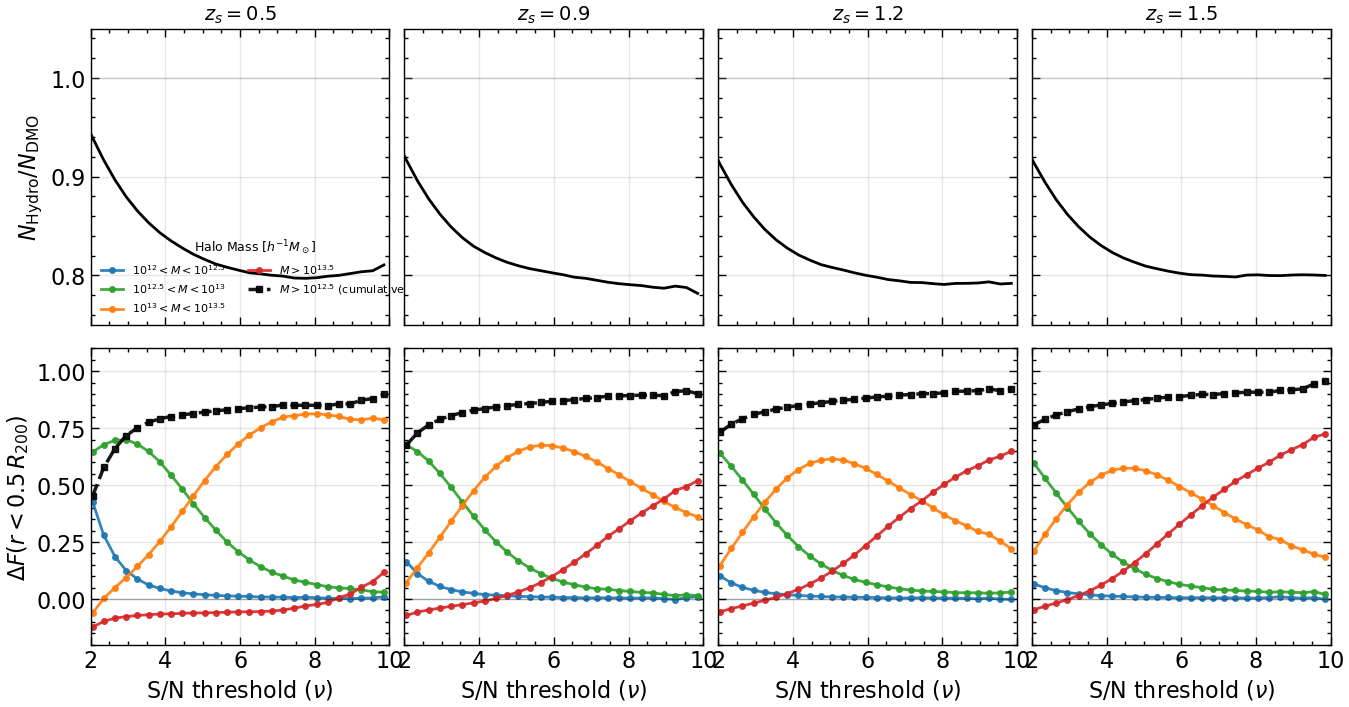


Saved to figures/core_response_by_mass_multiZ.png and .pdf


In [6]:
# ============================================================================
# PLOT: Halo Core Response (r < 0.5 R₂₀₀) by Mass Bin - PEAKS - Multi-redshift
# ============================================================================

# Redshift indices and labels (from kappa file mapping)
# kappa13 → z_s ≈ 0.51, kappa20 → z_s ≈ 0.86, kappa25 → z_s ≈ 1.16, kappa30 → z_s ≈ 1.53
z_indices = [13, 20, 25, 30]
z_labels = ['$z_s = 0.5$', '$z_s = 0.9$', '$z_s = 1.2$', '$z_s = 1.5$']

# Get S/N bin centers
sn_edges = base_stats['hydro']['sn_bin_edges']
sn_centers = 0.5 * (sn_edges[:-1] + sn_edges[1:])

# Create 8-panel figure (2 rows × 4 columns)
fig, axes = plt.subplots(2, 4, figsize=(16, 8), sharex=True, sharey='row',
                         gridspec_kw={'height_ratios': [1, 1], 'hspace': 0.08, 'wspace': 0.05})

# Colors and labels for mass bins
radius_idx = 0
colors = ['#1f77b4', '#2ca02c', '#ff7f0e', '#d62728']
mass_labels = [
    '$10^{12} < M < 10^{12.5}$',
    '$10^{12.5} < M < 10^{13}$', 
    '$10^{13} < M < 10^{13.5}$',
    '$M > 10^{13.5}$'
]

for col, (z_idx_plot, z_label) in enumerate(zip(z_indices, z_labels)):
    ax1 = axes[0, col]  # Top row
    ax2 = axes[1, col]  # Bottom row
    
    # --- Top panel: Hydro/DMO ratio ---
    dmo = base_stats['dmo']['peaks'][:, z_idx_plot, :].sum(axis=0)
    hydro = base_stats['hydro']['peaks'][:, z_idx_plot, :].sum(axis=0)
    N_dmo = np.cumsum(dmo[::-1])[::-1]
    N_hydro = np.cumsum(hydro[::-1])[::-1]
    delta_ratio = N_hydro / N_dmo
    
    ax1.plot(sn_centers, delta_ratio, 'k-', lw=2)
    ax1.axhline(1, color='gray', ls='-', lw=1, alpha=0.3)
    ax1.set_title(z_label, fontsize=14)
    ax1.grid(True, alpha=0.3)
    
    # --- Bottom panel: Response fraction ---
    for i in range(4):
        model = f'hydro_replace_Ml_{mass_bins[i]}_Mu_{mass_bin_upper[i]}_Ri_0.0_Ro_0.5'
        if model in disc_stats:
            # Recompute for this z_idx
            dmo_m = base_stats['dmo']['peaks'][:, z_idx_plot, :].sum(axis=0)
            hydro_m = base_stats['hydro']['peaks'][:, z_idx_plot, :].sum(axis=0)
            replace_m = disc_stats[model]['peaks'][:, z_idx_plot, :].sum(axis=0)
            
            N_dmo_m = np.cumsum(dmo_m[::-1])[::-1]
            N_hydro_m = np.cumsum(hydro_m[::-1])[::-1]
            N_replace_m = np.cumsum(replace_m[::-1])[::-1]
            
            delta = N_hydro_m - N_dmo_m
            F = np.where(np.abs(delta) > 50, (N_replace_m - N_dmo_m) / delta, np.nan)
            F_plot = np.clip(F, -1.5, 1.5)
            F_plot = np.where(sn_centers >= 2, F_plot, np.nan)
            
            ax2.plot(sn_centers, F_plot, 'o-', lw=2, markersize=4, 
                    label=mass_labels[i], color=colors[i], alpha=0.9)
    
    # Add cumulative model
    if cumulative_core_stats_peaks is not None:
        replace_cum = cumulative_core_stats_peaks['peaks'][:, z_idx_plot, :].sum(axis=0)
        N_replace_cum = np.cumsum(replace_cum[::-1])[::-1]
        
        dmo_c = base_stats['dmo']['peaks'][:, z_idx_plot, :].sum(axis=0)
        hydro_c = base_stats['hydro']['peaks'][:, z_idx_plot, :].sum(axis=0)
        N_dmo_c = np.cumsum(dmo_c[::-1])[::-1]
        N_hydro_c = np.cumsum(hydro_c[::-1])[::-1]
        delta_c = N_hydro_c - N_dmo_c
        
        F_cum = np.where(np.abs(delta_c) > 50, (N_replace_cum - N_dmo_c) / delta_c, np.nan)
        F_cum_plot = np.clip(F_cum, -1.5, 1.5)
        F_cum_plot = np.where(sn_centers >= 2, F_cum_plot, np.nan)
        ax2.plot(sn_centers, F_cum_plot, 's--', lw=2.5, markersize=5, 
                label='$M > 10^{12.5}$ (cumulative)', color='black', alpha=0.9)
    
    ax2.axhline(0, color='k', ls='-', lw=1, alpha=0.3)
    ax2.grid(True, alpha=0.3)
    ax2.set_xlim(2, 10)

# Set axis labels
axes[0, 0].set_ylabel('$N_{\\rm Hydro}/N_{\\rm DMO}$')
axes[1, 0].set_ylabel('$\\Delta F(r<0.5\\,R_{200})$')
for col in range(4):
    axes[1, col].set_xlabel('S/N threshold ($\\nu$)')

# Set y-limits
for ax in axes[0, :]:
    ax.set_ylim(0.75, 1.05)
for ax in axes[1, :]:
    ax.set_ylim(-0.2, 1.1)

# Add legend to first top panel
handles, labels = axes[1, 0].get_legend_handles_labels()
axes[0, 0].legend(handles, labels, loc='lower left', fontsize=8, 
                  title='Halo Mass [$h^{-1}M_\\odot$]', title_fontsize=9, ncols=2)

plt.tight_layout()
plt.savefig('figures/core_response_by_mass_multiZ.png', dpi=150, bbox_inches='tight')
plt.savefig('figures/core_response_by_mass_multiZ.pdf', format='pdf', bbox_inches='tight')
plt.show()

print("\nSaved to figures/core_response_by_mass_multiZ.png and .pdf")

In [39]:
# ============================================================================
# Load minima data
# ============================================================================
print("Loading minima statistics...")
base_stats_minima = {
    'dmo': load_stats('dmo', keys=['minima', 'sn_bin_edges']),
    'hydro': load_stats('hydro', keys=['minima', 'sn_bin_edges'])
}

disc_stats_minima = {}
for model in DISC_MODELS:
    stats = load_stats(model, keys=['minima', 'sn_bin_edges'])
    if stats is not None:
        disc_stats_minima[model] = stats
print(f"Loaded {len(disc_stats_minima)} discrete models with minima")

# Load cumulative model: M > 10^12.5, r < 0.5 R₂₀₀
cumulative_core_model = 'hydro_replace_Ml_3.16e12_Mu_1.00e15_Ri_0.0_Ro_0.5'
cumulative_core_stats = load_stats(cumulative_core_model, keys=['minima', 'sn_bin_edges'])
if cumulative_core_stats is not None:
    print(f"Loaded cumulative core model: {cumulative_core_model}")
else:
    print(f"WARNING: Could not load cumulative core model: {cumulative_core_model}")

Loading minima statistics...


Loaded 16 discrete models with minima
Loaded cumulative core model: hydro_replace_Ml_3.16e12_Mu_1.00e15_Ri_0.0_Ro_0.5


In [10]:
def compute_deltaF_vs_nu_minima(model_stats, base_stats, z_idx):
    """Compute ΔF for each S/N bin for minima (negative ν)."""
    sn_edges = base_stats['hydro']['sn_bin_edges']
    sn_centers = 0.5 * (sn_edges[:-1] + sn_edges[1:])
    
    # Sum over realizations for each S/N bin
    dmo = base_stats['dmo']['minima'][:, z_idx, :].sum(axis=0)
    hydro = base_stats['hydro']['minima'][:, z_idx, :].sum(axis=0)
    replace = model_stats['minima'][:, z_idx, :].sum(axis=0)
    
    # Cumulative counts from low S/N to high (for minima, we go from most negative)
    N_dmo = np.cumsum(dmo)
    N_hydro = np.cumsum(hydro)
    N_replace = np.cumsum(replace)
    
    # Response fraction
    delta = N_hydro - N_dmo
    F = np.where(np.abs(delta) > 50, (N_replace - N_dmo) / delta, np.nan)
    
    return sn_centers, F

# Compute ΔF vs ν for all discrete tiles (minima)
print("Computing response fractions for minima...")
tile_data_minima = {}

for i, (ml, mu) in enumerate(zip(mass_bins, mass_bin_upper)):
    for j, (ri, ro) in enumerate(radius_bins):
        model = f'hydro_replace_Ml_{ml}_Mu_{mu}_Ri_{ri}_Ro_{ro}'
        if model in disc_stats_minima:
            nu, F = compute_deltaF_vs_nu_minima(disc_stats_minima[model], base_stats_minima, z_idx)
            tile_data_minima[(i, j)] = (nu, F)

print(f"Computed response for {len(tile_data_minima)} tiles")

Computing response fractions for minima...
Computed response for 16 tiles


/tmp/ipykernel_1444946/2912151037.py:18: RuntimeWarning: invalid value encountered in divide
  F = np.where(np.abs(delta) > 50, (N_replace - N_dmo) / delta, np.nan)


/tmp/ipykernel_1444946/973208250.py:52: RuntimeWarning: invalid value encountered in divide
  F_m = np.where(np.abs(delta_m) > 50, (N_replace_m - N_dmo_m) / delta_m, np.nan)
/tmp/ipykernel_1444946/973208250.py:87: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


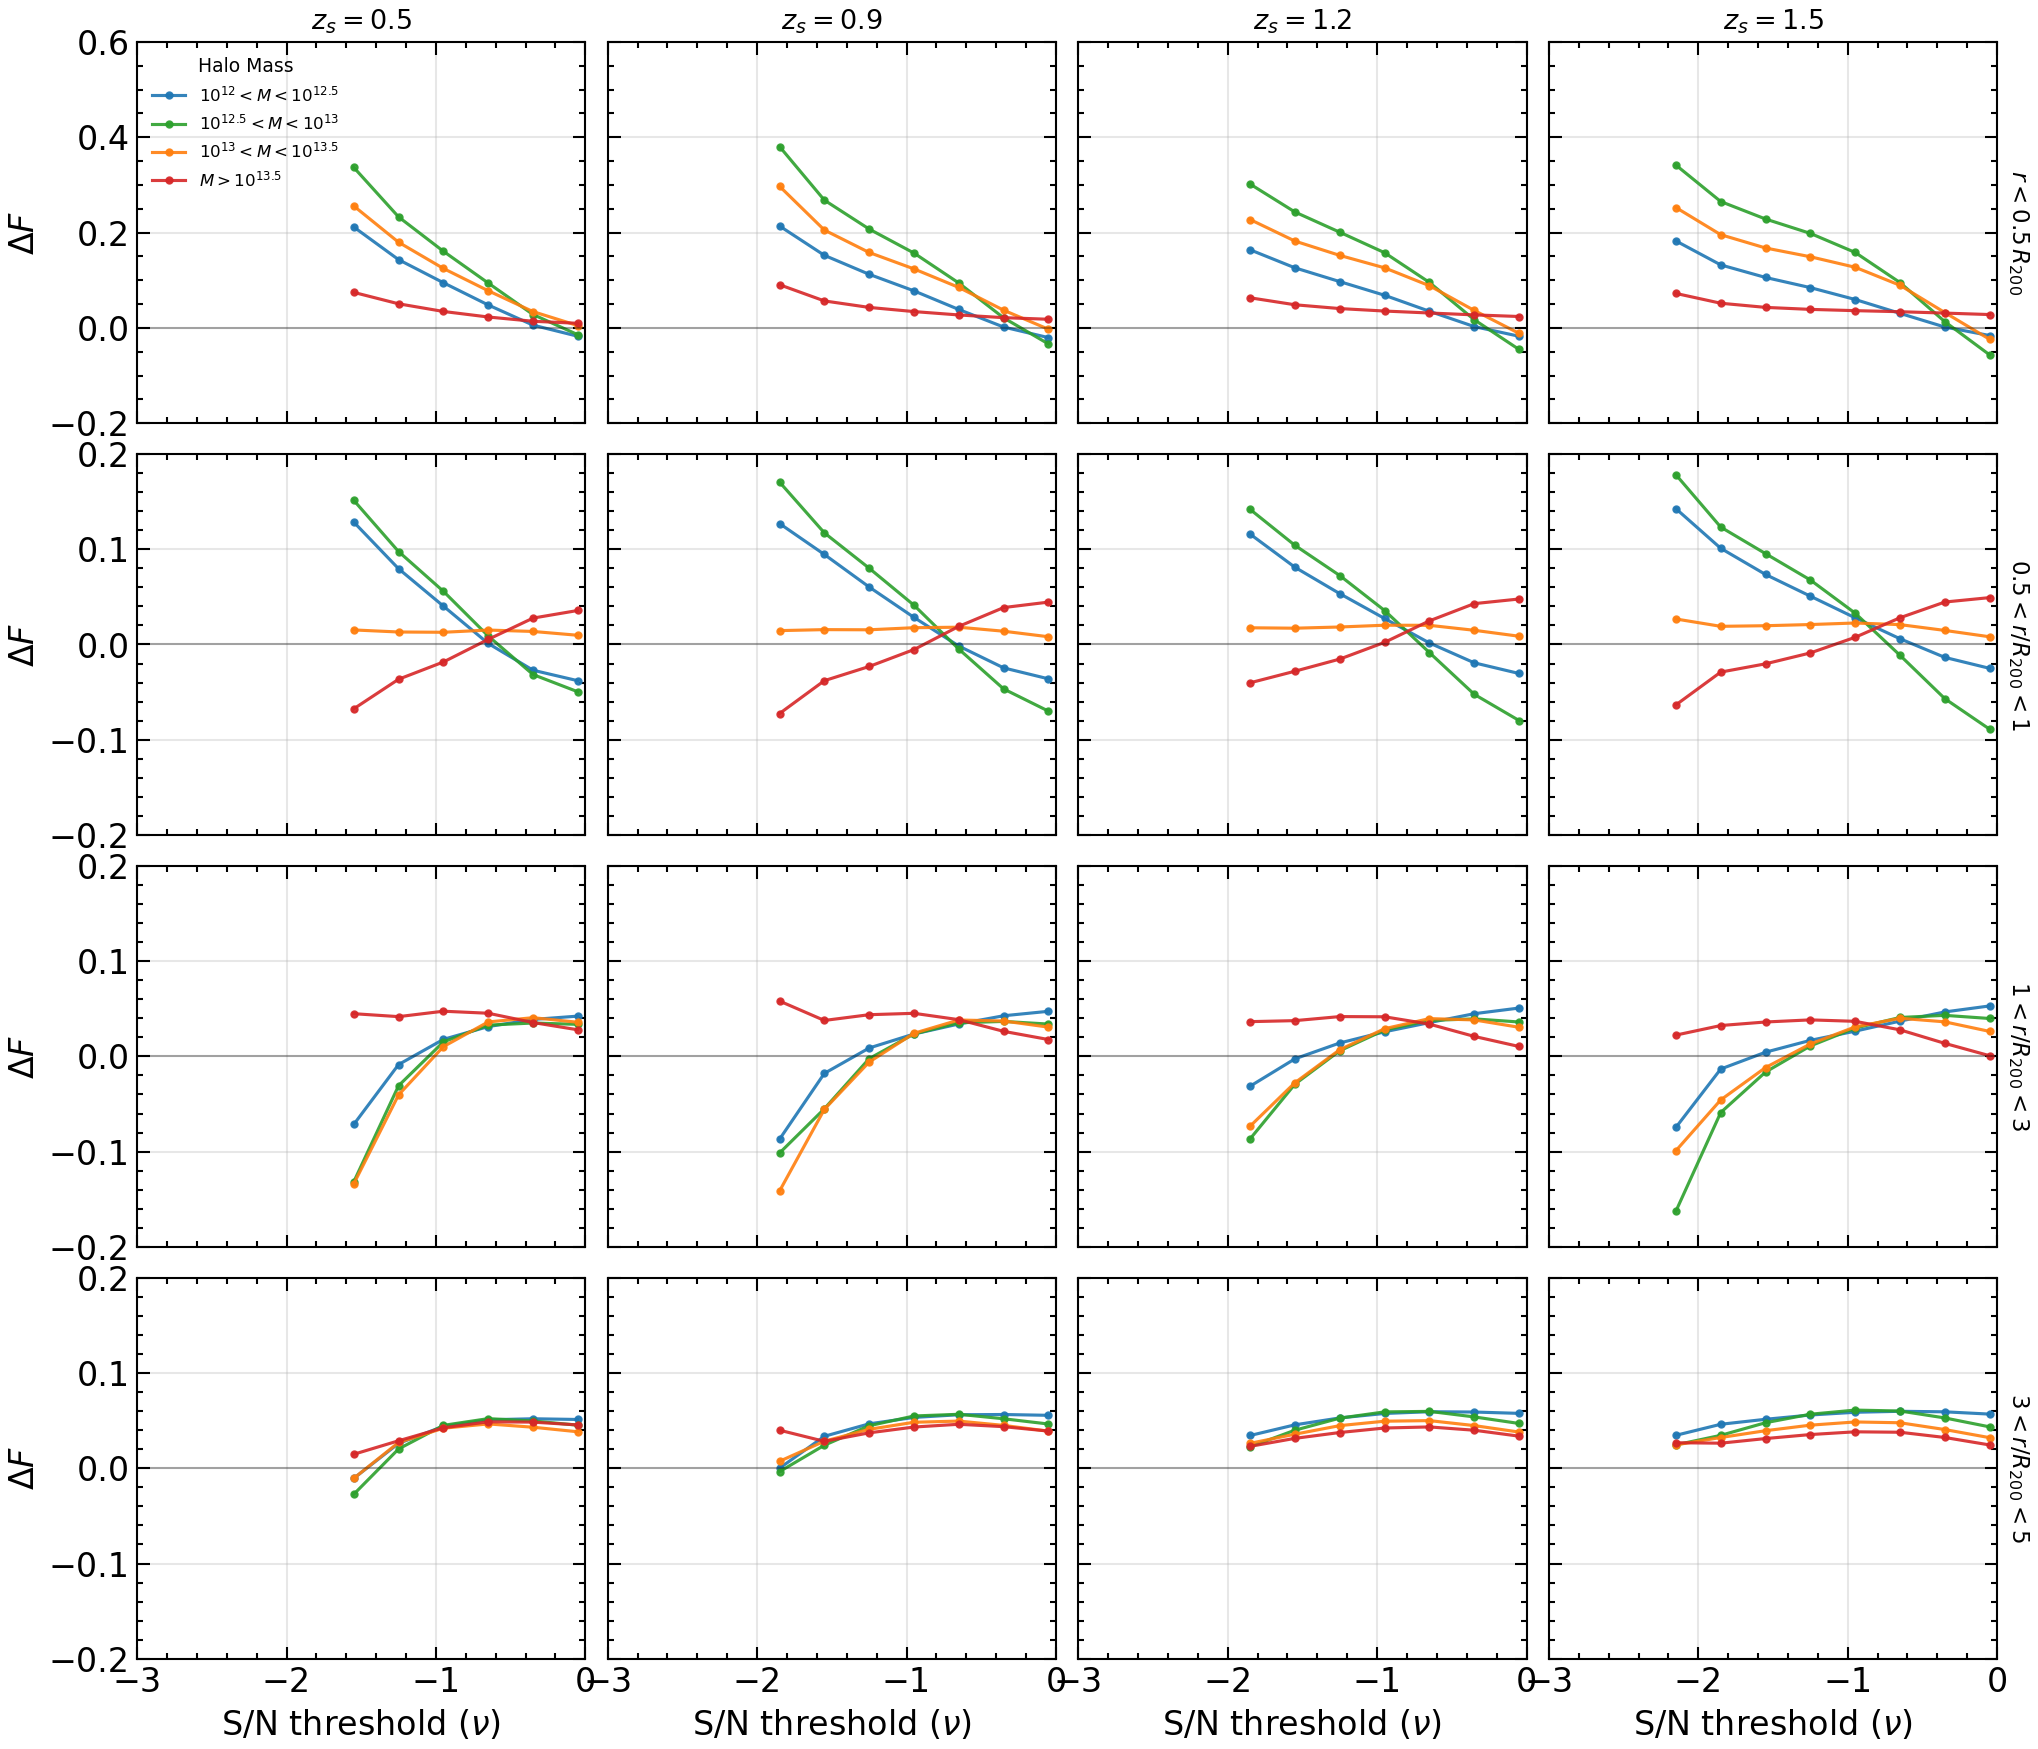


Saved to figures/radial_response_minima_multiZ.png and .pdf


In [55]:
# ============================================================================
# PLOT: Full Response by Radial Shell - MINIMA - Multi-redshift
# ============================================================================

# Redshift indices and labels
z_indices = [13, 20, 25, 30]
z_labels = ['$z_s = 0.5$', '$z_s = 0.9$', '$z_s = 1.2$', '$z_s = 1.5$']

# Get S/N bin centers
sn_edges = base_stats_minima['hydro']['sn_bin_edges']
sn_centers = 0.5 * (sn_edges[:-1] + sn_edges[1:])

# Radial shell definitions
radial_shells = [
    ('0.0', '0.5', '$r < 0.5\\,R_{200}$'),
    ('0.5', '1.0', '$0.5 < r/R_{200} < 1$'),
    ('1.0', '3.0', '$1 < r/R_{200} < 3$'),
    ('3.0', '5.0', '$3 < r/R_{200} < 5$'),
]

# Colors and labels for mass bins
colors = ['#1f77b4', '#2ca02c', '#ff7f0e', '#d62728']
mass_labels = [
    '$10^{12} < M < 10^{12.5}$',
    '$10^{12.5} < M < 10^{13}$', 
    '$10^{13} < M < 10^{13.5}$',
    '$M > 10^{13.5}$'
]

# Create 16-panel figure (4 rows for radial shells × 4 columns for redshifts)
fig, axes = plt.subplots(4, 4, figsize=(16, 14), sharex=True, sharey='row',
                         gridspec_kw={'hspace': 0.08, 'wspace': 0.05})

for row, (ri, ro, r_label) in enumerate(radial_shells):
    for col, (z_idx_plot, z_label) in enumerate(zip(z_indices, z_labels)):
        ax = axes[row, col]
        
        # Compute response for each mass bin - MINIMA
        for i in range(4):
            model = f'hydro_replace_Ml_{mass_bins[i]}_Mu_{mass_bin_upper[i]}_Ri_{ri}_Ro_{ro}'
            if model in disc_stats_minima:
                dmo_m = base_stats_minima['dmo']['minima'][:, z_idx_plot, :].sum(axis=0)
                hydro_m = base_stats_minima['hydro']['minima'][:, z_idx_plot, :].sum(axis=0)
                replace_m = disc_stats_minima[model]['minima'][:, z_idx_plot, :].sum(axis=0)
                
                # Cumulative from most negative
                N_dmo_m = np.cumsum(dmo_m)
                N_hydro_m = np.cumsum(hydro_m)
                N_replace_m = np.cumsum(replace_m)
                
                delta_m = N_hydro_m - N_dmo_m
                F_m = np.where(np.abs(delta_m) > 50, (N_replace_m - N_dmo_m) / delta_m, np.nan)
                F_m_plot = np.clip(F_m, -1.5, 1.5)
                F_m_plot = np.where(sn_centers <= 0, F_m_plot, np.nan)
                
                ax.plot(sn_centers, F_m_plot, 'o-', lw=1.5, markersize=3, 
                       color=colors[i], alpha=0.9, label=mass_labels[i] if (row==0 and col==0) else None)
        
        ax.axhline(0, color='k', ls='-', lw=1, alpha=0.3)
        ax.grid(True, alpha=0.3)
        ax.set_xlim(-3, 0)
        
        # Add titles
        if row == 0:
            ax.set_title(z_label, fontsize=13)
        
        # Add radial shell label on right side
        if col == 3:
            ax.annotate(r_label, xy=(1.02, 0.5), xycoords='axes fraction',
                       fontsize=11, ha='left', va='center', rotation=-90)

# Set axis labels
for row in range(4):
    axes[row, 0].set_ylabel('$\\Delta F$')
for col in range(4):
    axes[3, col].set_xlabel('S/N threshold ($\\nu$)')

# Set y-limits for each row
axes[0, 0].set_ylim(-0.2, 0.6)   # Core
axes[1, 0].set_ylim(-0.2, 0.2)   # 0.5-1.0 R200
axes[2, 0].set_ylim(-0.2, 0.2)   # 1-3 R200
axes[3, 0].set_ylim(-0.2, 0.2)   # 3-5 R200

# Add legend
axes[0, 0].legend(loc='upper left', fontsize=8, title='Halo Mass', title_fontsize=9)

plt.tight_layout()
plt.savefig('figures/radial_response_minima_multiZ.png', dpi=150, bbox_inches='tight')
plt.savefig('figures/radial_response_minima_multiZ.pdf', format='pdf', bbox_inches='tight')
plt.show()

print("\nSaved to figures/radial_response_minima_multiZ.png and .pdf")

In [15]:
# Debug: check why data cuts off at ν = -2
sn_edges = base_stats_minima['hydro']['sn_bin_edges']
sn_centers = 0.5 * (sn_edges[:-1] + sn_edges[1:])

dmo = base_stats_minima['dmo']['minima'][:, z_idx, :].sum(axis=0)
hydro = base_stats_minima['hydro']['minima'][:, z_idx, :].sum(axis=0)

# Cumulative counts
N_dmo = np.cumsum(dmo)
N_hydro = np.cumsum(hydro)
delta = N_hydro - N_dmo

print("S/N centers (negative only):")
print(sn_centers[sn_centers < 0])
print("\nCumulative counts for ν < 0:")
for i, nu in enumerate(sn_centers):
    if nu < 0:
        print(f"  ν={nu:6.2f}: N_dmo={N_dmo[i]:8.0f}, N_hydro={N_hydro[i]:8.0f}, delta={delta[i]:8.0f}")

S/N centers (negative only):
[-4.85       -4.55       -4.25       -3.9499998  -3.65       -3.35
 -3.0500002  -2.75       -2.4499998  -2.15       -1.85       -1.55
 -1.25       -0.95000005 -0.65       -0.35       -0.05      ]

Cumulative counts for ν < 0:
  ν= -4.85: N_dmo=       0, N_hydro=       0, delta=       0
  ν= -4.55: N_dmo=       0, N_hydro=       0, delta=       0
  ν= -4.25: N_dmo=       0, N_hydro=       0, delta=       0
  ν= -3.95: N_dmo=       0, N_hydro=       0, delta=       0
  ν= -3.65: N_dmo=       0, N_hydro=       0, delta=       0
  ν= -3.35: N_dmo=       0, N_hydro=       0, delta=       0
  ν= -3.05: N_dmo=       0, N_hydro=       0, delta=       0
  ν= -2.75: N_dmo=       0, N_hydro=       0, delta=       0
  ν= -2.45: N_dmo=       0, N_hydro=       0, delta=       0
  ν= -2.15: N_dmo=       0, N_hydro=       0, delta=       0
  ν= -1.85: N_dmo=     353, N_hydro=      77, delta=    -276
  ν= -1.55: N_dmo=  475559, N_hydro=  226257, delta= -249302
  ν= -1.25: N

In [13]:
sn_bins

NameError: name 'sn_bins' is not defined